# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

This data represents the findings of 17 marketing campaigns from May 2008 to November 2010. With almost 80,000 different contacts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score,
    roc_curve,
)

In [2]:
df = pd.read_csv("./data/bank-additional-full.csv", sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

From both the column descriptions and examination of the nulls in the dataset, there are no explicit 'null' or NaN values. However, there are nulls in the semantic sense. Several columns use 'unknown' as a placeholder. These should be handled as nulls through imputing them. Another column specifically, pdays, should have values of '999' treated as null since by it's own description it means the customer was not contacted.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The primary business objective is to enhance the efficiency of the bank's marketing campaigns by identifying customers with the highest propensity to subscribe to a term deposit. To accomplish this, several binary classification models will be developed and compared to determine the most accurate approach for predicting customer behavior.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [6]:
df["job"].unique()

<StringArray>
[    'housemaid',      'services',        'admin.',   'blue-collar',
    'technician',       'retired',    'management',    'unemployed',
 'self-employed',       'unknown',  'entrepreneur',       'student']
Length: 12, dtype: str

In [7]:
df["education"].unique()

<StringArray>
[           'basic.4y',         'high.school',            'basic.6y',
            'basic.9y', 'professional.course',             'unknown',
   'university.degree',          'illiterate']
Length: 8, dtype: str

In [8]:
# Fix the job column
df["job"] = df["job"].replace("admin.", "admin")

In [9]:
# Handle the 'unknown' values throughout the data
df = df.replace("unknown", np.nan)

df = df.drop(columns=["duration"])

# Handle the 999 in the 'pdays' column
df["pdays"] = df["pdays"].replace(999, np.nan)

# Binarize the target column
df["y"] = df["y"].map({"yes": 1, "no": 0})

# Ordinal encode the education levels
edu_order = [
    [
        "illiterate",
        "basic.4y",
        "basic.6y",
        "basic.9y",
        "high.school",
        "professional.course",
        "university.degree",
    ]
]
oe = OrdinalEncoder(
    categories=edu_order, handle_unknown="use_encoded_value", unknown_value=np.nan
)
df["education"] = oe.fit_transform(df[["education"]])

# One-hot encode the categorical columns
categorical_cols = [
    "job",
    "marital",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

numeric_cols = [
    "age",
    "campaign",
    "pdays",
    "duration",
    "emp.var.rate",
    "cons.price.idx",
]

In [10]:
pd.concat(
    [df["y"].value_counts(), df["y"].value_counts(normalize=True).mul(100)],
    axis=1,
    keys=["Count", "Percentage (%)"],
)

,Count,Percentage (%)
y,,
0,36548,88.734583
1,4640,11.265417


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:
X = df.drop("y", axis=1)
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

imputer = SimpleImputer(strategy="median")  # median is robust to outliers
X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])  # ←

In [13]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  #

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Noting above, our target column is heavily imbalanced. About 89% of the values are 'no', and thus accuracy would be a poor metric to use. This will be the baseline, and we can see this with the use of a Dummy Classifier.

In [14]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(classification_report(y_test, y_pred_dummy, zero_division=0.0))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7310
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238

ROC-AUC: 0.5


After having the naive model 'predict' the majority class, we can see what our real models need to beat. The F1 score for the model should be greater than 0.00, since the 'yes' class is what we care about. And the ROC-AUC score needs to be better than 0.5 (which is just random guessing).

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    )
}
start = time.time()
models["Logistic Regression"].fit(X_train, y_train)
end = time.time() - start
y_pred = models["Logistic Regression"].predict(X_test)
y_prob = models["Logistic Regression"].predict_proba(X_test)[:, 1]

results = {
    "Logistic Regression": {
        "Train Time": round(end, 4),
        "Train Accuracy": round(
            models["Logistic Regression"].score(X_train, y_train), 4
        ),
        "Test Accuracy": round(models["Logistic Regression"].score(X_test, y_test), 4),
    }
}

### Problem 9: Score the Model

What is the accuracy of your model?

In [16]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

ROC-AUC: 0.8011708983914336


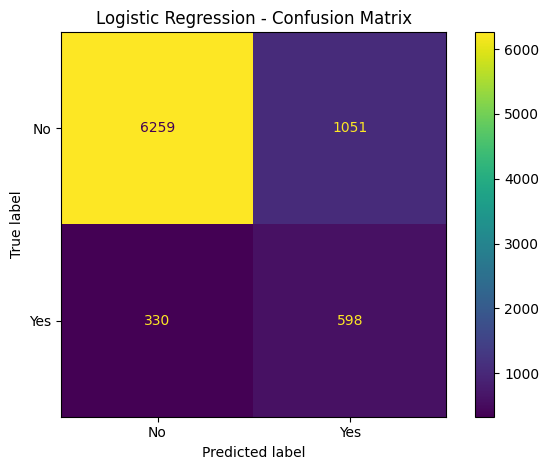

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No", "Yes"])
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

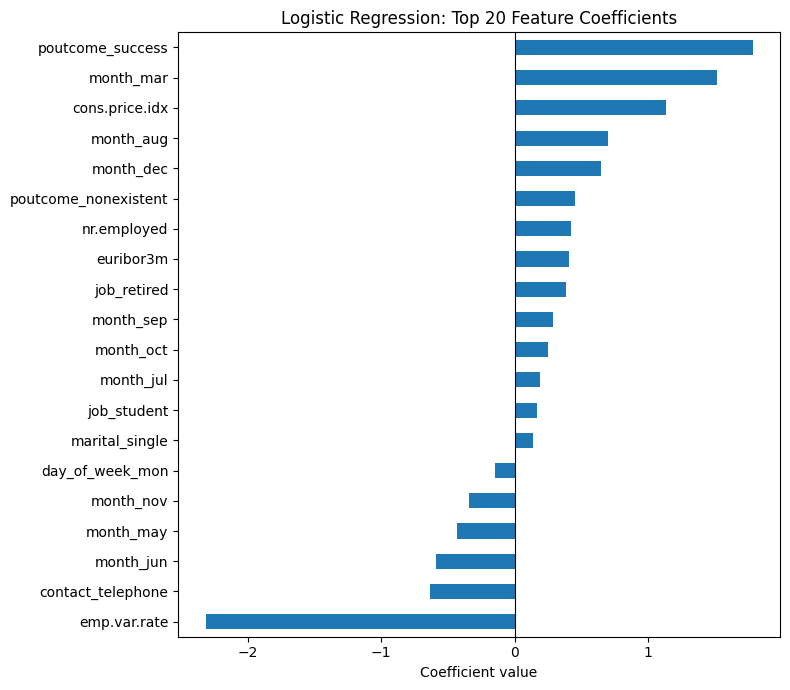

In [18]:
coefs = pd.Series(models["Logistic Regression"].coef_[0], index=X_train.columns)
top20 = coefs.abs().nlargest(20).index
fig, ax = plt.subplots(figsize=(8, 7))
coefs[top20].sort_values().plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression: Top 20 Feature Coefficients")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [19]:
models.update(
    {
        "KNN": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "SVM": SVC(random_state=42, probability=True),
    }
)
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Train Time": round(end, 4),
        "Train Accuracy": round(model.score(X_train, y_train), 4),
        "Test Accuracy": round(model.score(X_test, y_test), 4),
    }

    print(f"\n{'='*50}")
    print(name)
    print("=" * 50)
    print(classification_report(y_test, y_pred, zero_division=0.0))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

ROC-AUC: 0.8012

KNN
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.55      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238

ROC-AUC: 0.7419

Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      7310
           1       0.31      0.34      0.32       928

    accuracy                           0.84      8238
   macro avg       0.61      0.62      0.62      8238
w

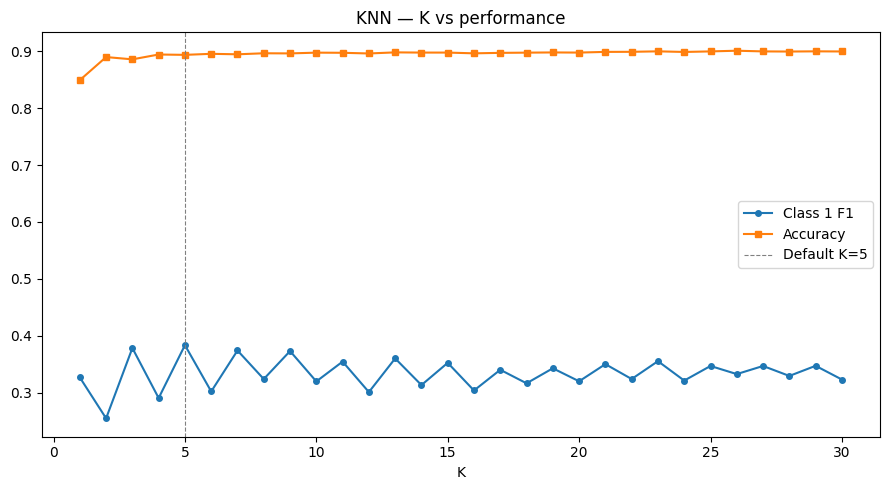

In [20]:
k_values = range(1, 31)
f1s, accs = [], []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    preds = knn_k.predict(X_test)
    f1s.append(f1_score(y_test, preds))
    accs.append((preds == y_test).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, f1s, label="Class 1 F1", marker="o", markersize=4)
ax.plot(k_values, accs, label="Accuracy", marker="s", markersize=4)
ax.axvline(5, color="gray", linestyle="--", linewidth=0.8, label="Default K=5")
ax.set_xlabel("K")
ax.set_title("KNN — K vs performance")
ax.legend()
plt.tight_layout()
plt.show()

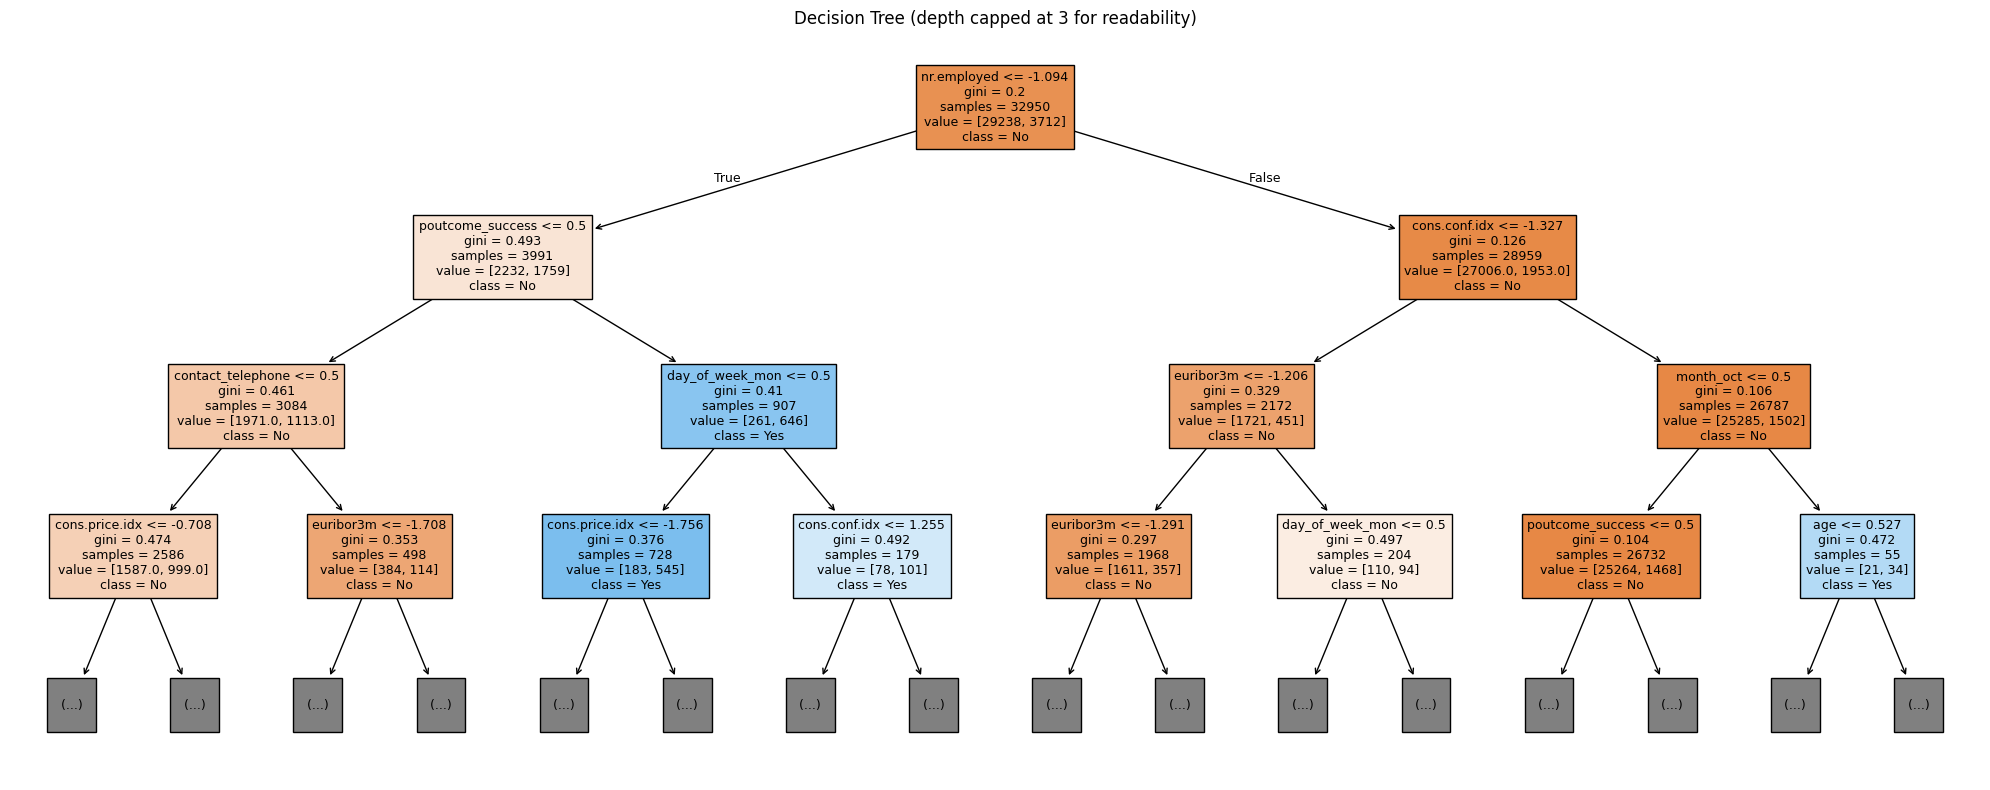

In [21]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    models["Decision Tree"],
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True,
    max_depth=3,
    ax=ax,
    fontsize=9,
)
ax.set_title("Decision Tree (depth capped at 3 for readability)")
plt.tight_layout()
plt.show()

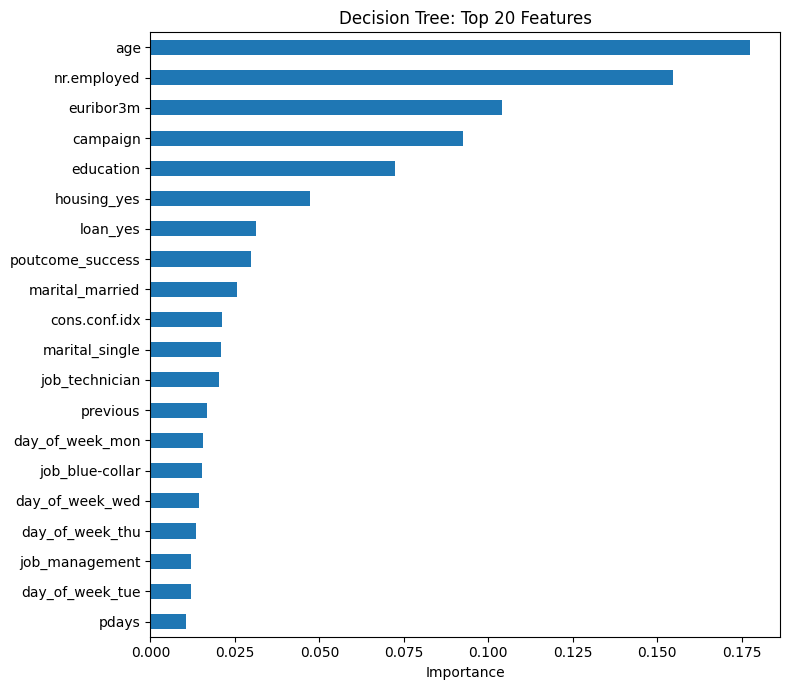

In [22]:
dt_importances = pd.Series(
    models["Decision Tree"].feature_importances_, index=X_train.columns
)
top20_dt = dt_importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 7))
top20_dt.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Decision Tree: Top 20 Features")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

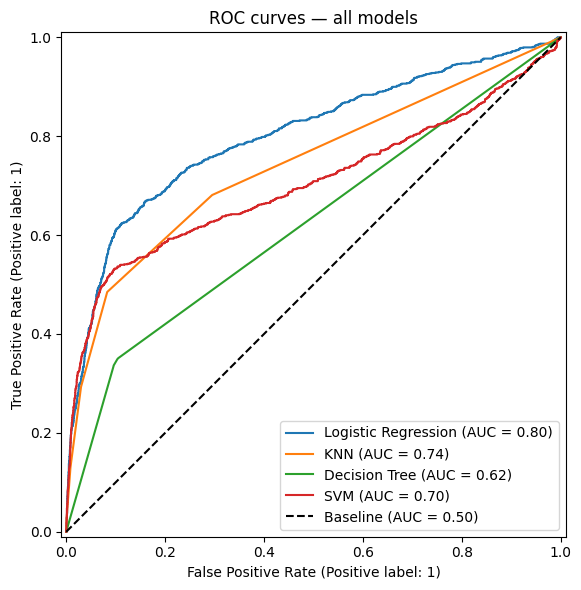

In [23]:
y_probs = {
    "Logistic Regression": models["Logistic Regression"].predict_proba(X_test)[:, 1],
    "KNN": models["KNN"].predict_proba(X_test)[:, 1],
    "Decision Tree": models["Decision Tree"].predict_proba(X_test)[:, 1],
    "SVM": models["SVM"].predict_proba(X_test)[:, 1],
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob in y_probs.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Baseline (AUC = 0.50)")
ax.set_title("ROC curves — all models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Looking a plot of the ROC-AUC curves of each model, it's easy to see that Logistic Regression outperformed every other model before any tuning.

In [24]:
models_summary = (
    pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
)
models_summary

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.0400,0.8290,0.8324
1,KNN,0.0021,0.9130,0.8938
2,Decision Tree,0.0953,0.9947,0.8401
3,SVM,70.4194,0.9062,0.9025


From these training and test accuracy results, we can see that **logistic regression** is the clear winner. The **decision tree** classifier is overfitting massively, training accuracy of ~99% and a 84% test accuracy. This might point to limiting the max depth parameter to tune that model.

As for the **KNN** classifier, it also overfits, but to a lesser degree. And although the train and test accuracy for **SVM** has the smallest gap, demonstrating good generalization, it takes over a minute to train. Whereas the other models take less than a 10th of a second. This would be extremely costly as the dataset size scales.

Out of all of the models with no tuning, Logistic Regression is the most honest, while taking very little time to train. Also comparing it's ROC-AUC and F1 scores, it was the best performing model of the four.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

To tune the models, we'll use GridSearchCV to find the best parameters.

In [25]:
# Setup parameters for each model
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(
            class_weight="balanced", max_iter=5000, random_state=42
        ),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs", "liblinear", "saga"],
        },
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": range(5, 31, 2),
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"],
        },
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "params": {
            "max_depth": [3, 5, 7, 10, 15],
            "min_samples_split": [2, 10, 20, 50],
            "min_samples_leaf": [1, 5, 10],
        },
    },
    "SVM": {
        "model": CalibratedClassifierCV(
            LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)
        ),
        "params": {
            "estimator__C": [0.01, 0.1, 1, 10],
        },
    },
}

In [26]:
tuned_results = {}
best_models = {}

# Run grid search CV for each model with their parameters
for name, config in param_grids.items():
    print("=" * 50)
    print(f"Tuning {name}...")
    gs = GridSearchCV(
        config["model"],
        config["params"],
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_train, y_train)

    # Get model predictions
    best_models[name] = gs.best_estimator_
    # Time the fitting each model
    start = time.time()
    gs.best_estimator_.fit(X_train, y_train)
    fit_time = time.time() - start

    y_pred = gs.predict(X_test)
    y_prob = gs.best_estimator_.predict_proba(X_test)[:, 1]

    # Print the best params, F1, train and test, and ROC-AUC scores
    print(f"Best params: {gs.best_params_}")
    print(f"CV F1:       {gs.best_score_:.4f}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC:     {roc_auc_score(y_test, y_prob):.4f}")

    # Save the results to a separate dictionary
    tuned_results[name] = {
        "Train Time (s)": round(fit_time, 4),
        "Train Accuracy": round(gs.best_estimator_.score(X_train, y_train), 4),
        "Test Accuracy": round(gs.best_estimator_.score(X_test, y_test), 4),
        "CV F1": round(gs.best_score_, 4),
        "Test F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Best Params": gs.best_params_,
    }

Tuning Logistic Regression...
Best params: {'C': 100, 'solver': 'lbfgs'}
CV F1:       0.4497
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

ROC-AUC:     0.8012
Tuning KNN...
Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
CV F1:       0.3529
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.55      0.30      0.39       928

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238

ROC-AUC:     0.7458
Tuning Decision Tree...
Best params: {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 50}

In [27]:
tuned_summary = (
    pd.DataFrame(tuned_results)
    .T.reset_index()
    .rename(columns={"index": "Model"})
    .drop(columns="Best Params")
)
tuned_summary

,Model,Train Time (s),Train Accuracy,Test Accuracy,CV F1,Test F1,ROC-AUC
0,Logistic Regression,0.0371,0.8294,0.8328,0.4497,0.4648,0.8012
1,KNN,0.0024,0.9114,0.8935,0.3529,0.3871,0.7458
2,Decision Tree,0.0444,0.8344,0.839,0.462,0.4759,0.7987
3,SVM,0.4426,0.8984,0.8992,0.3194,0.323,0.8007


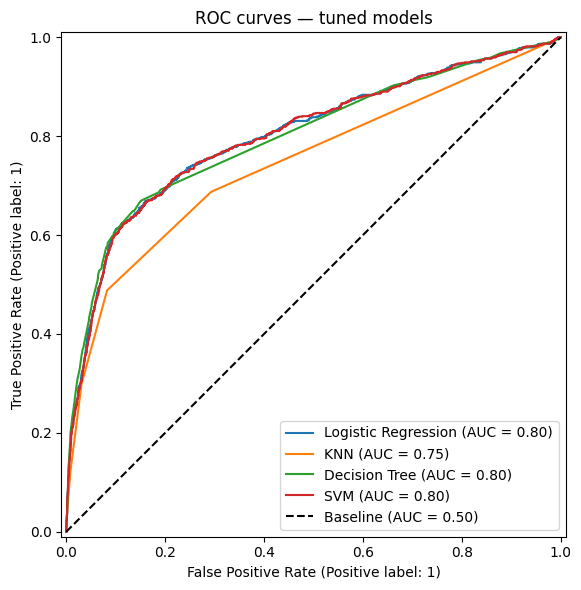

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Baseline (AUC = 0.50)")
ax.set_title("ROC curves — tuned models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

After grid searching all four models, with additional tuning, there are other contenders. The decision tree and logistic regression models are basically tied, with an AUC score of 0.8 and an F1 score of 0.48 and 0.46 respectively. We can see even with tuning that KNN and SVM both weaker, despite a high test score.

As a final recommendation, the tuned **Logistic Regression** model would be the best choice for several reasons.
- **Performance**: An ROC-AUC score of 0.8 and recall of 0.64 makes it the best performer of the four after tuning
- **Training Time**: One of the fastest to train models with only 0.04 seconds on ~41,000 rows
- **Not Overfitting**: With a nearly identical training and test accuracy, the model should be quite stable with new data
- **Interpretability**: The coefficients can be used directly to gain business insights as to what is predictive of a successful campaign

With this tuned logistic regression model, the bank's marketing team can focus on calling the customers who are most likely to subscribe a deposit. Although there is a trade-off for efficiency with 36% of predicted missed subscribers, this can be tuned by adjusting the classification threshold depending on the specific marketing goals at the time.